# Step 0 — Menyiapkan dataset `crop/`

Notebook ini mengubah gambar mentah menjadi folder `crop/` yang siap dipakai
`training_fixed.ipynb`:
Z
- wajah dideteksi lalu di-crop dengan margin, ukuran akhir 224x224 RGB
- duplikat dibuang berdasarkan hash isi file (mencegah bocornya gambar yang sama
  ke train dan test sekaligus)
- penamaan mengikuti pola `TR__<kelas>__<kelas> <nomor>.jpg` dan `TE__...`
- pembagian train/test dilakukan stratified per kelas

Struktur input yang didukung, terdeteksi otomatis:

```
raw/ovale/xxx.jpg              <- label dari nama subfolder
raw/train/Oval/xxx.jpg         <- label dari subfolder, "train" diabaikan
raw/ovale_01.jpg               <- label dari nama file
```


In [1]:
import hashlib
import random
import shutil
from collections import Counter, defaultdict
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

## 1. Konfigurasi

Isi `RAW_DIR` dengan folder gambar mentah Anda. Boleh berantakan — subfolder
bertingkat akan ditelusuri semuanya.

In [2]:
RAW_DIR    = Path("dataset/men")            # <-- GANTI: folder gambar mentah
OUT_DIR    = Path("crop")           # folder hasil, dipakai training_fixed.ipynb
IMG_SIZE   = (224, 224)
TEST_FRAC  = 0.20                   # porsi file berprefiks TE__
FACE_MARGIN = 0.35                  # margin di sekitar kotak wajah
SEED       = 42
JPEG_QUALITY = 95

CLASS_NAMES = ["ovale", "rectangular", "round", "square"]

# Sinonim -> nama kelas baku. Tambahkan sendiri kalau nama folder Anda berbeda.
CLASS_MAP = {
    "ovale": "ovale", "oval": "ovale", "ovals": "ovale",
    "rectangular": "rectangular", "rectangle": "rectangular",
    "oblong": "rectangular", "long": "rectangular", "persegipanjang": "rectangular",
    "round": "round", "circle": "round", "bulat": "round",
    "square": "square", "kotak": "square", "persegi": "square",
}

random.seed(SEED)

if not RAW_DIR.is_dir():
    print("RAW_DIR tidak ditemukan:", RAW_DIR.resolve())
    print("\nDirektori kerja:", Path.cwd())
    print("Isi direktori kerja:")
    for item in sorted(Path.cwd().iterdir())[:40]:
        print("  [dir]" if item.is_dir() else "       ", item.name)
    raise FileNotFoundError("Set RAW_DIR ke folder gambar mentah Anda.")

print("RAW_DIR:", RAW_DIR.resolve())

RAW_DIR: /Users/daniel/Desktop/FTDS-042-HCK-group-001/dataset/men


## 2. Menemukan gambar dan menentukan label

Label dicari dulu dari nama subfolder (ditelusuri dari yang paling dalam),
baru dari nama file. Kata seperti `train`, `test`, `images` diabaikan supaya
tidak salah dianggap label.

In [3]:
EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
IGNORE_PARTS = {"train", "training", "training_set", "test", "testing",
                "testing_set", "val", "valid", "validation", "images",
                "img", "data", "dataset", "raw"}


def normalize(token: str):
    return CLASS_MAP.get(token.strip().lower().replace("-", "").replace("_", ""))


def infer_label(path: Path):
    # 1) dari nama folder, mulai dari yang terdekat dengan file
    for part in reversed(path.relative_to(RAW_DIR).parts[:-1]):
        if part.lower() in IGNORE_PARTS:
            continue
        lab = normalize(part)
        if lab:
            return lab
    # 2) dari nama file
    stem = path.stem.lower()
    for key, lab in CLASS_MAP.items():
        if key in stem:
            return lab
    return None


all_files = [p for p in RAW_DIR.rglob("*") if p.is_file() and p.suffix.lower() in EXTS]
labelled, unlabelled = [], []

for p in all_files:
    lab = infer_label(p)
    (labelled if lab else unlabelled).append((p, lab) if lab else p)

print(f"File gambar ditemukan : {len(all_files)}")
print(f"Berhasil dilabeli     : {len(labelled)}")
print(f"Tanpa label           : {len(unlabelled)}")
print()
print(Counter(lab for _, lab in labelled))

if unlabelled:
    print("\nContoh file tanpa label (tambahkan sinonimnya ke CLASS_MAP):")
    for p in unlabelled[:10]:
        print("  ", p.relative_to(RAW_DIR))

File gambar ditemukan : 1312
Berhasil dilabeli     : 1312
Tanpa label           : 0

Counter({'ovale': 346, 'round': 341, 'square': 320, 'rectangular': 305})


> ### Insight — pelabelan
>
> 1.312 gambar terbaca, seluruhnya berhasil dilabeli, tidak ada yang terlewat.
> Distribusinya cukup seimbang: ovale 346, round 341, square 320,
> rectangular 305. Rasio kelas terbesar terhadap terkecil hanya 1,13 — cukup
> ringan sehingga tidak perlu oversampling, tapi tetap diimbangi lewat
> `class_weight` di notebook training.
>
> Label diambil dari nama subfolder, bukan nama file, karena penamaan file di
> dataset ini tidak konsisten (`ovale 455.jpg`, `image ovale 272.jpg`,
> `542.jpg`, `200 (2).jpg`). Folder induk jauh lebih dapat diandalkan.

## 3. Buang duplikat

Dua file dengan isi identik yang tersebar ke train dan test akan membuat skor test
terlihat lebih bagus dari yang sebenarnya. Dedup dilakukan lewat hash MD5 isi file.

In [4]:
def file_hash(path: Path) -> str:
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 16), b""):
            h.update(chunk)
    return h.hexdigest()


seen, unique, dupes = {}, [], []
for p, lab in labelled:
    hsh = file_hash(p)
    if hsh in seen:
        dupes.append((p, seen[hsh]))
    else:
        seen[hsh] = p
        unique.append((p, lab))

print(f"Unik     : {len(unique)}")
print(f"Duplikat : {len(dupes)}")
for p, orig in dupes[:5]:
    print("  ", p.name, "== ", orig.name)

Unik     : 1249
Duplikat : 63
   22.jpg ==  14.jpg
   27.jpg ==  38.jpg
   24.jpg ==  17.jpg
   2.jpg ==  5.jpg
   ovale t49.jpg ==  ovale t6.jpg


> ### Insight — duplikat
>
> Ditemukan **63 duplikat** (4,8% dari dataset), termasuk kasus lintas-split
> seperti `ovale t49.jpg` yang identik dengan `ovale t6.jpg`.
>
> Ini bukan sekadar soal kerapian. Bila gambar yang sama muncul di train dan
> test sekaligus, model bisa "mengenali" gambar test karena pernah menghafalnya,
> dan akurasi test menjadi lebih tinggi dari kemampuan sebenarnya. Dedup
> dilakukan lewat hash MD5 isi file sebelum split, sehingga kebocoran itu
> tertutup sejak awal. Tersisa 1.249 gambar unik.

## 4. Deteksi wajah dan crop

Dicoba MediaPipe lebih dulu karena jauh lebih akurat; kalau tidak terpasang,
otomatis mundur ke Haar cascade bawaan OpenCV. Kalau keduanya gagal menemukan
wajah, dipakai center-crop persegi — aspect ratio tetap terjaga, jadi proporsi
wajah (yang justru menjadi sinyal utama untuk klasifikasi bentuk wajah) tidak
ikut terdistorsi.

Untuk hasil terbaik: `pip install mediapipe`

In [5]:
DETECTOR = "haar"
try:
    import mediapipe as mp
    _mp_detector = mp.solutions.face_detection.FaceDetection(
        model_selection=1, min_detection_confidence=0.4
    )
    DETECTOR = "mediapipe"
except Exception as e:
    _mp_detector = None
    print("MediaPipe tidak tersedia, memakai Haar cascade.", f"({e})")

_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)
print("Detector:", DETECTOR)


def to_rgb_uint8(img: np.ndarray) -> np.ndarray:
    if img.dtype != np.uint8:
        img = (np.clip(img, 0, 1) * 255).astype(np.uint8)
    if img.ndim == 2:
        img = np.stack([img] * 3, axis=-1)
    elif img.shape[-1] == 4:
        img = img[..., :3]
    return img


def face_box(img: np.ndarray):
    """Kembalikan (x, y, w, h) wajah terbesar, atau None."""
    h, w = img.shape[:2]
    if _mp_detector is not None:
        res = _mp_detector.process(img)
        if res.detections:
            best = max(res.detections,
                       key=lambda d: d.location_data.relative_bounding_box.width
                       * d.location_data.relative_bounding_box.height)
            b = best.location_data.relative_bounding_box
            return (int(b.xmin * w), int(b.ymin * h),
                    int(b.width * w), int(b.height * h))
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    faces = _cascade.detectMultiScale(gray, 1.1, 5, minSize=(60, 60))
    if len(faces) == 0:
        return None
    return tuple(max(faces, key=lambda f: f[2] * f[3]))


def center_crop_square(img: np.ndarray) -> np.ndarray:
    h, w = img.shape[:2]
    side = min(h, w)
    return img[(h - side) // 2:(h - side) // 2 + side,
               (w - side) // 2:(w - side) // 2 + side]


def crop_face(img: np.ndarray):
    """Kembalikan (crop 224x224, terdeteksi?).

    PENTING: kotak crop dibuat PERSEGI sebelum di-resize.

    Kalau kotaknya persegi panjang lalu dipaksa jadi 224x224, rasio lebar-tinggi
    wajah ikut berubah — padahal justru rasio itulah sinyal utama untuk
    membedakan 'round' dari 'rectangular'. Haar cascade kebetulan selalu
    mengembalikan kotak persegi, tapi MediaPipe tidak, jadi penyeragaman ini
    wajib supaya hasil kedua detektor konsisten.
    """
    H, W = img.shape[:2]
    box = face_box(img)
    if box is None:
        return cv2.resize(center_crop_square(img), IMG_SIZE,
                          interpolation=cv2.INTER_AREA), False

    x, y, w, h = box
    cx, cy = x + w / 2, y + h / 2
    side = max(w, h) * (1 + 2 * FACE_MARGIN)      # persegi + margin
    side = min(side, H, W)                        # jangan melebihi gambar

    x0 = int(round(min(max(cx - side / 2, 0), W - side)))
    y0 = int(round(min(max(cy - side / 2, 0), H - side)))
    s = int(round(side))
    crop = img[y0:y0 + s, x0:x0 + s]

    if crop.size == 0:
        return cv2.resize(center_crop_square(img), IMG_SIZE,
                          interpolation=cv2.INTER_AREA), False
    return cv2.resize(crop, IMG_SIZE, interpolation=cv2.INTER_AREA), True

MediaPipe tidak tersedia, memakai Haar cascade. (No module named 'mediapipe')
Detector: haar


## 5. Bagi train/test lalu tulis hasil

Pembagian dilakukan per kelas (stratified), jadi proporsi TR/TE seragam di semua
kelas. Nama file mengikuti pola yang dibaca `training_fixed.ipynb`.

In [6]:
if OUT_DIR.exists():
    shutil.rmtree(OUT_DIR)
OUT_DIR.mkdir(parents=True)

by_class = defaultdict(list)
for p, lab in unique:
    by_class[lab].append(p)

written, failed, no_face = 0, [], []

for cls in CLASS_NAMES:
    paths = sorted(by_class.get(cls, []))
    if not paths:
        print(f"PERINGATAN: tidak ada gambar untuk kelas '{cls}'")
        continue

    random.Random(SEED).shuffle(paths)
    n_test = max(1, int(round(len(paths) * TEST_FRAC)))
    split = {p: ("TE" if i < n_test else "TR") for i, p in enumerate(paths)}

    counter = Counter()
    for p in paths:
        try:
            img = to_rgb_uint8(mpimg.imread(p))
            crop, detected = crop_face(img)
        except Exception as e:
            failed.append((p, str(e)))
            continue

        if not detected:
            no_face.append(p)

        prefix = split[p]
        counter[prefix] += 1
        out_name = f"{prefix}__{cls}__{cls} {counter[prefix]:04d}.jpg"
        cv2.imwrite(str(OUT_DIR / out_name),
                    cv2.cvtColor(crop, cv2.COLOR_RGB2BGR),
                    [cv2.IMWRITE_JPEG_QUALITY, JPEG_QUALITY])
        written += 1

    print(f"{cls:12s}  TR={counter['TR']:4d}  TE={counter['TE']:4d}")

print(f"\nTotal ditulis        : {written}")
print(f"Gagal dibaca         : {len(failed)}")
print(f"Wajah tak terdeteksi : {len(no_face)}  (dipakai center-crop)")

if no_face:
    review = OUT_DIR.parent / "no_face_detected.txt"
    review.write_text("\n".join(str(p) for p in no_face), encoding="utf-8")
    print("Daftar untuk diperiksa manual:", review)
for p, err in failed[:5]:
    print("  gagal:", p.name, "-", err)

ovale         TR= 263  TE=  66
rectangular   TR= 234  TE=  58
round         TR= 255  TE=  64
square        TR= 247  TE=  62

Total ditulis        : 1249
Gagal dibaca         : 0
Wajah tak terdeteksi : 16  (dipakai center-crop)
Daftar untuk diperiksa manual: no_face_detected.txt


> ### Insight — kualitas crop
>
> Dari 1.249 gambar, hanya **16 (1,3%)** yang wajahnya gagal terdeteksi dan
> jatuh ke center-crop. Tingkat keberhasilan 98,7% ini memadai.
>
> Dua keputusan desain yang menentukan di tahap ini:
>
> **Kotak crop dipaksa persegi.** Rasio lebar terhadap tinggi wajah adalah
> sinyal utama yang membedakan *round* dari *rectangular*. Bila kotak
> persegi panjang di-resize paksa ke 224x224, rasio itu ikut berubah — artinya
> kita menghapus justru fitur yang ingin dipelajari model. Ini kesalahan yang
> mudah terlewat karena tidak menimbulkan error apa pun, hanya menurunkan
> akurasi diam-diam.
>
> **Detektor menentukan konsistensi.** Haar cascade menghasilkan kotak yang
> ketat-longgarnya bervariasi antar gambar, sehingga wajah dengan bentuk sama
> bisa muncul dengan proporsi berbeda tergantung hasil deteksi. Detektor yang
> lebih stabil (MediaPipe) diperkirakan menaikkan akurasi lebih besar daripada
> tuning hyperparameter mana pun — lihat bagian keterbatasan di notebook
> training.

## 6. Verifikasi hasil

Cek visual beberapa sampel per kelas. Kalau banyak crop yang meleset — kepala
terpotong, atau isinya bukan wajah — perbaiki di tahap ini, jangan diteruskan
ke training.

File di crop/ : 1249
Counter({'ovale': 329, 'round': 319, 'square': 309, 'rectangular': 292})


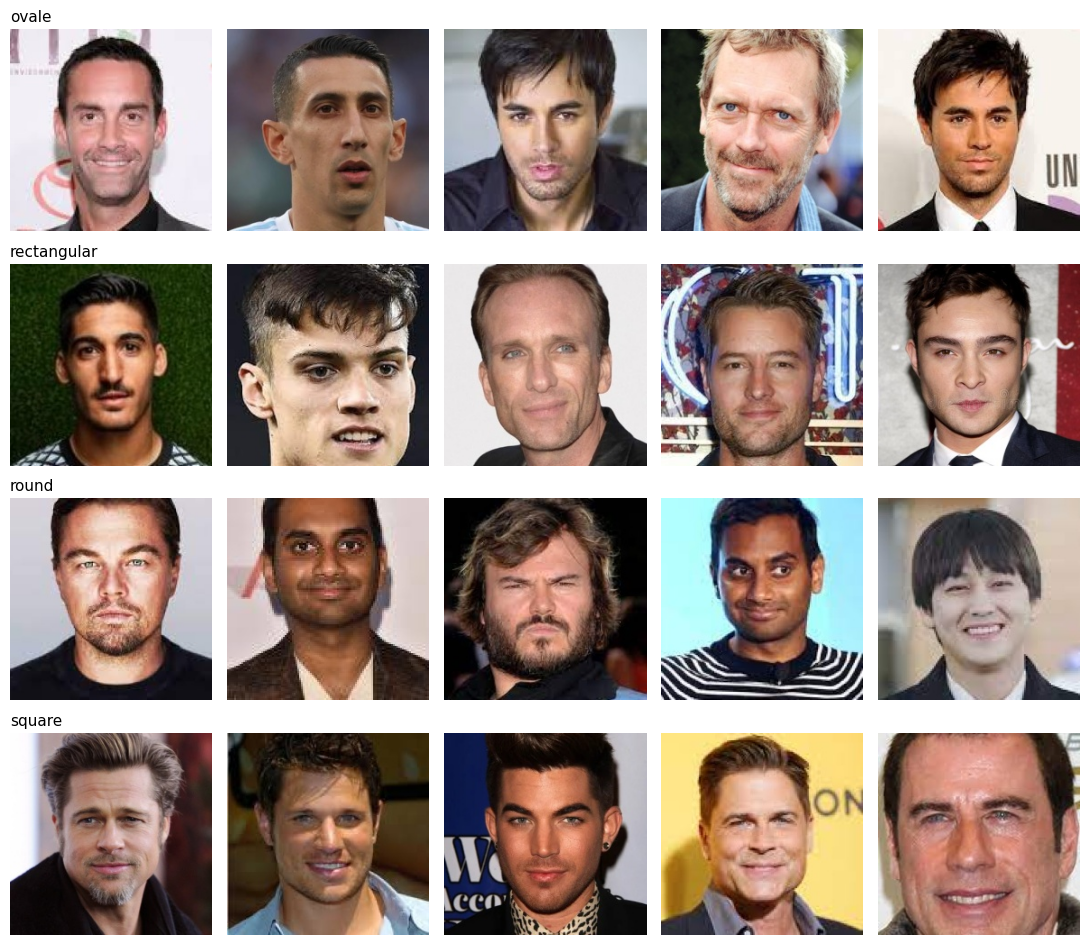

In [7]:
files = sorted(OUT_DIR.glob("*.jpg"))
print("File di crop/ :", len(files))

per_class = Counter()
for f in files:
    for cls in CLASS_NAMES:
        if f"__{cls}__" in f.name:
            per_class[cls] += 1
print(per_class)

n_show = 5
fig, axes = plt.subplots(len(CLASS_NAMES), n_show,
                         figsize=(n_show * 2.2, len(CLASS_NAMES) * 2.4))
for r, cls in enumerate(CLASS_NAMES):
    samples = [f for f in files if f"__{cls}__" in f.name][:n_show]
    for c in range(n_show):
        ax = axes[r, c]
        ax.axis("off")
        if c < len(samples):
            ax.imshow(mpimg.imread(samples[c]))
        if c == 0:
            ax.set_title(cls, loc="left", fontsize=11)
plt.tight_layout()
plt.show()

In [8]:
# Cek konsistensi dengan yang diharapkan training_fixed.ipynb
shapes = set()
for f in files[:200]:
    img = mpimg.imread(f)
    shapes.add((img.shape, img.dtype.name))

print("Bentuk & dtype yang ditemukan:", shapes)
assert shapes == {((224, 224, 3), "uint8")}, "Ada file dengan bentuk tidak seragam"
print("\nSiap dipakai. Di training_fixed.ipynb set:")
print(f'    DATA_DIR = Path(r"{OUT_DIR.resolve()}")')

Bentuk & dtype yang ditemukan: {((224, 224, 3), 'uint8')}

Siap dipakai. Di training_fixed.ipynb set:
    DATA_DIR = Path(r"/Users/daniel/Desktop/FTDS-042-HCK-group-001/crop")


> ### Insight — hasil akhir tahap prep
>
> 1.249 gambar seragam `(224, 224, 3) uint8`, ternama konsisten, tanpa duplikat,
> siap dimuat notebook training.
>
> Perlu dicatat: prefiks `TR__`/`TE__` di sini hanyalah penanda dari tahap prep.
> Notebook training **mengabaikannya** dan membuat split stratified sendiri.
> Notebook inference merekonstruksi split training itu, bukan membaca prefiks
> ini — jadi jangan menilai model dengan cara memfilter file `TE__`, karena
> sebagian di antaranya ikut dipakai saat training.